In [154]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

In [155]:
data=pd.read_csv('/content/loan_approval_dataset.csv')
pd.set_option('display.max_columns', None)
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [156]:
# checking number of rows and columns
rows, columns=data.shape
print(f'Dataset has {rows} rows and {columns} columns')

Dataset has 4269 rows and 13 columns


In [157]:
# checking number of categorical and numerical features
num, obj = 0,0
for feat in data.columns:
    if data[feat].dtypes=='O':
        obj +=1
    else:
        num +=1

print(f'Dataset has {num} numerical features and {obj} categorical features')

Dataset has 10 numerical features and 3 categorical features


In [158]:
# checking dupliicates
rows, columns=data[data.duplicated].shape
print('Dataset has no duplicates.' if rows==0 else f'Dataset has {rows} duplicates.')

Dataset has no duplicates.


In [159]:
# checking data type and missing values
data_types=pd.DataFrame(data.dtypes, columns=['Data_type'])
missing_value=pd.DataFrame(data.isnull().mean()*100, columns=['Missing_percentage'])
data_concat=pd.concat([data_types, missing_value], axis=1)
data_concat

,Data_type,Missing_percentage
loan_id,int64,0.0
no_of_dependents,int64,0.0
education,object,0.0
self_employed,object,0.0
income_annum,int64,0.0
loan_amount,int64,0.0
loan_term,int64,0.0
cibil_score,int64,0.0
residential_assets_value,int64,0.0
commercial_assets_value,int64,0.0


In [160]:
data.describe().round(2)

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.0,4269.0,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.0,2.5,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.5,1.7,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.0,0.0,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.0,1.0,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.0,3.0,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.0,4.0,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.0,5.0,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [161]:
data.columns = data.columns.str.strip()

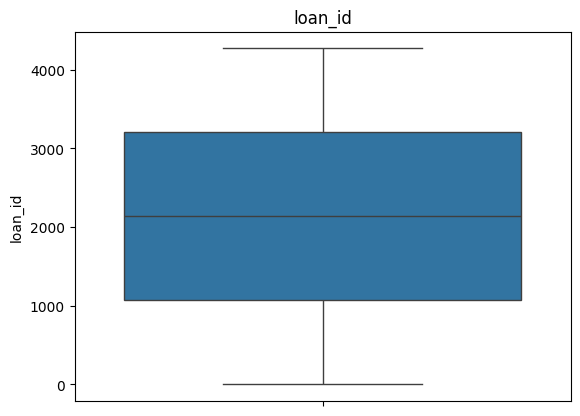

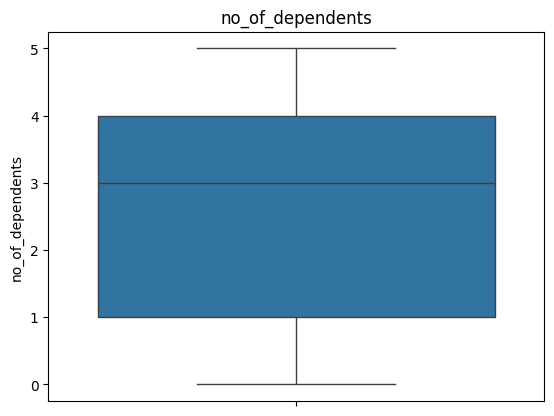

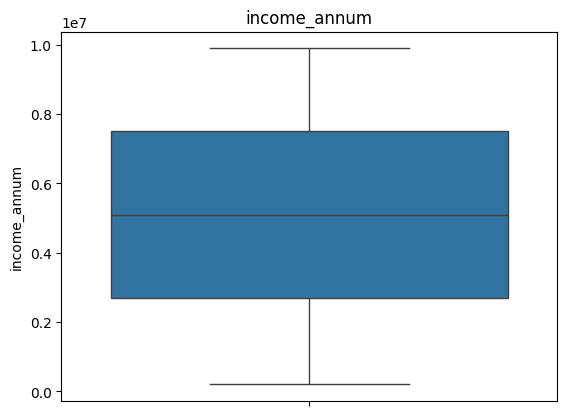

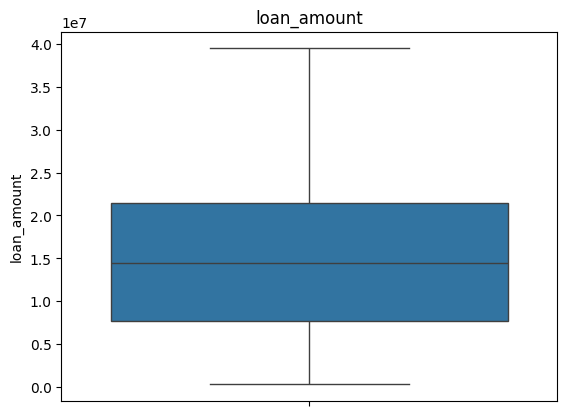

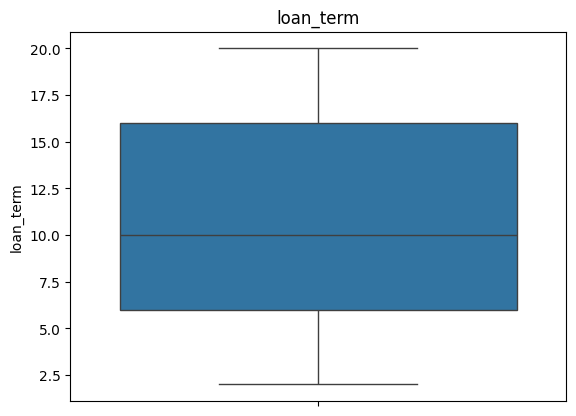

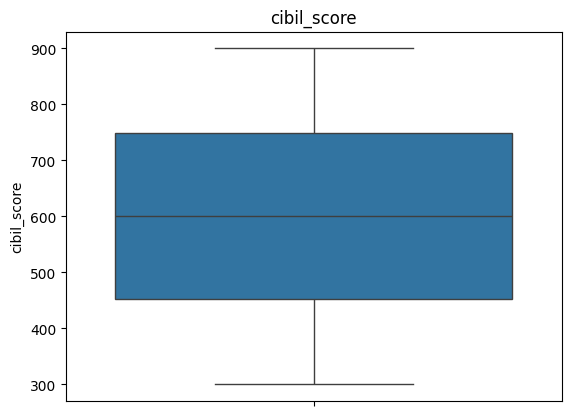

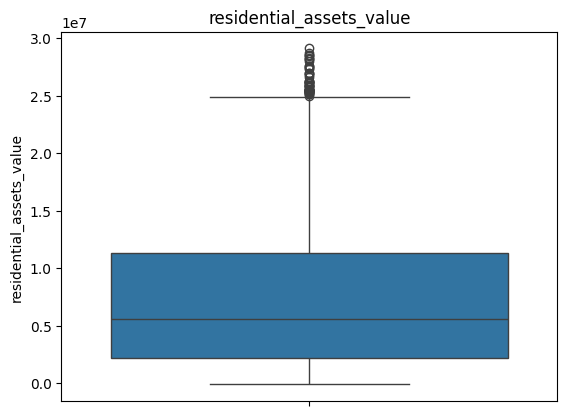

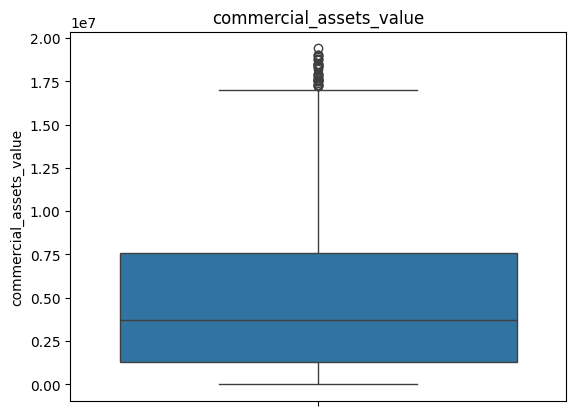

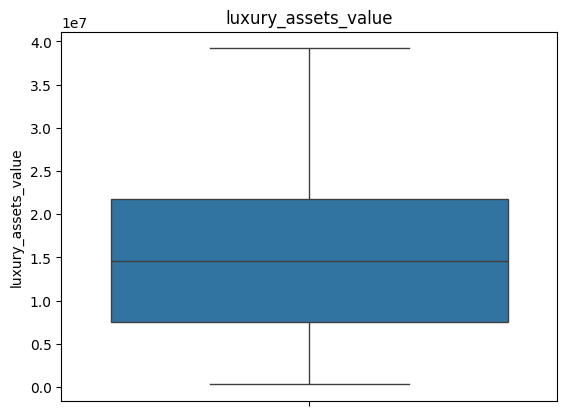

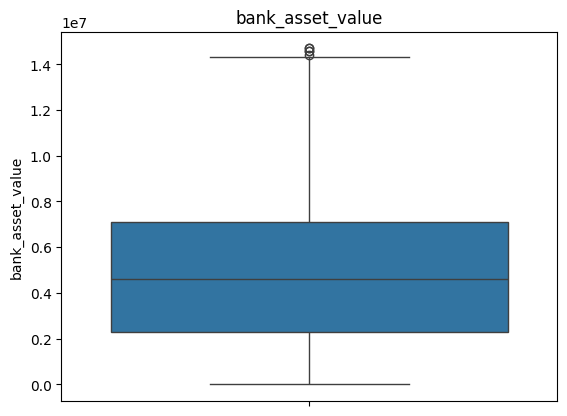

In [162]:
# checking outlier
def boxplots(col):
    sns.boxplot(data[col])
    plt.title(col)
    plt.show()

for i in list(data.select_dtypes(exclude=['object']).columns):
    boxplots(i)

In [163]:
Q1=data['residential_assets_value'].quantile(0.25)
Q3=data['residential_assets_value'].quantile(0.75)
IQR=Q3 - Q1

lower=Q1 - 1.5*IQR
upper=Q3 + 1.5*IQR

data['residential_assets_value']=np.where(data['residential_assets_value']>upper, upper, np.where(data['residential_assets_value']<lower, lower, data['residential_assets_value']))

In [164]:
Q1=data['commercial_assets_value'].quantile(0.25)
Q3=data['commercial_assets_value'].quantile(0.75)
IQR=Q3 - Q1

lower=Q1 - 1.5*IQR
upper=Q3 + 1.5*IQR

data['commercial_assets_value']=np.where(data['commercial_assets_value']>upper, upper, np.where(data['commercial_assets_value']<lower, lower, data['commercial_assets_value']))

In [165]:
Q1=data['bank_asset_value'].quantile(0.25)
Q3=data['bank_asset_value'].quantile(0.75)
IQR=Q3 - Q1

lower=Q1 - 1.5*IQR
upper=Q3 + 1.5*IQR

data['bank_asset_value']=np.where(data['bank_asset_value']>upper, upper, np.where(data['bank_asset_value']<lower, lower, data['bank_asset_value']))

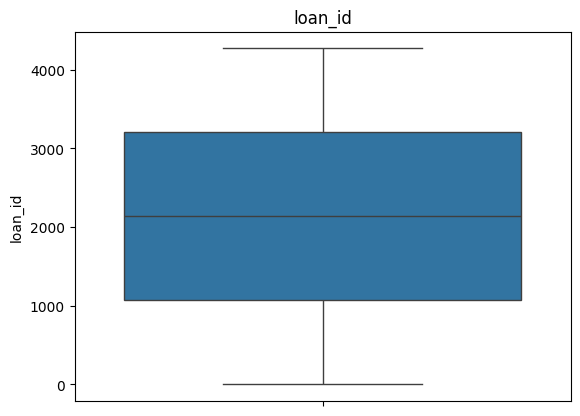

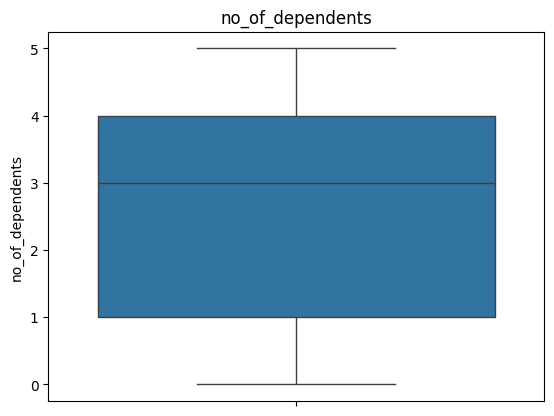

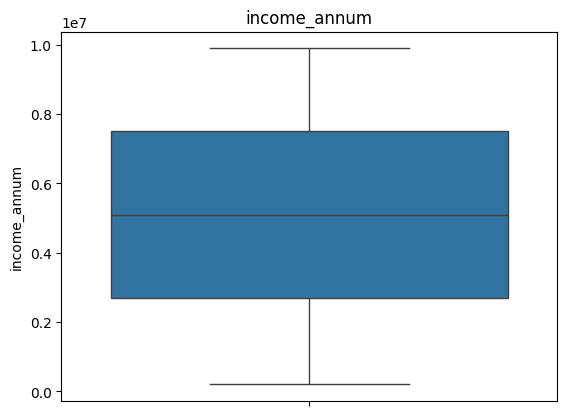

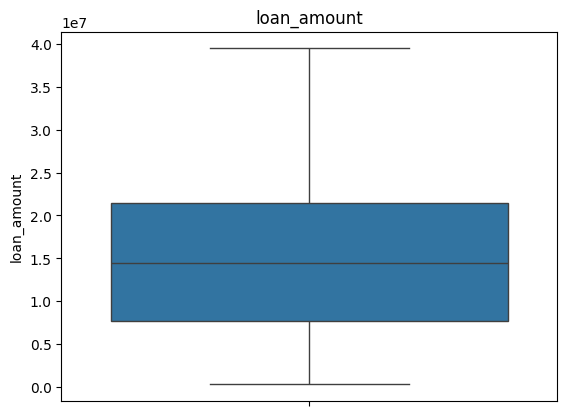

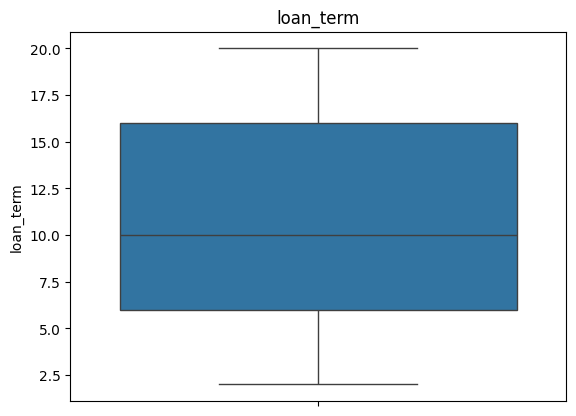

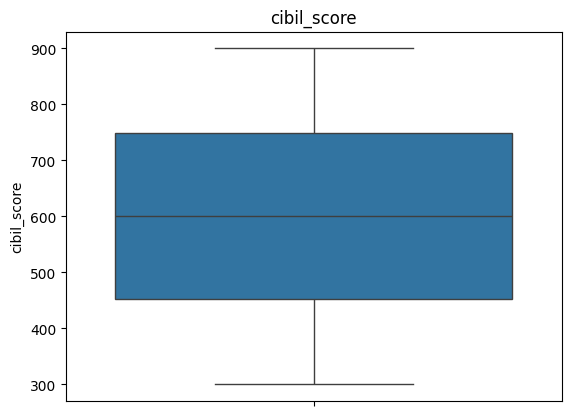

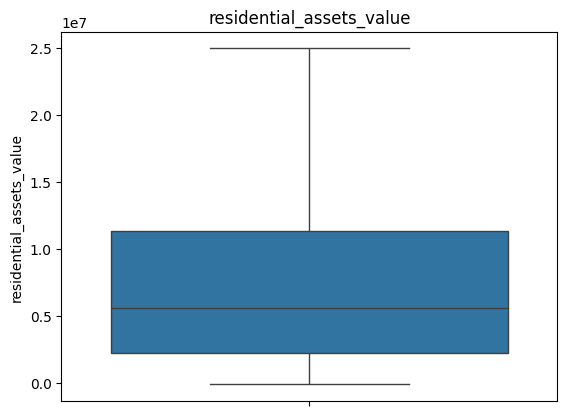

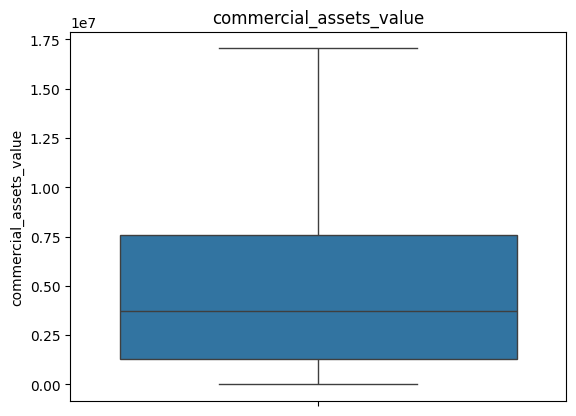

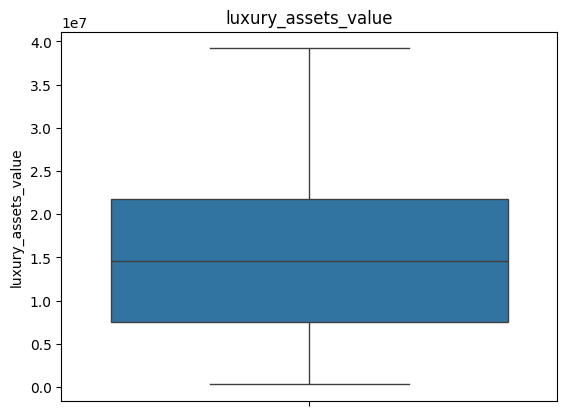

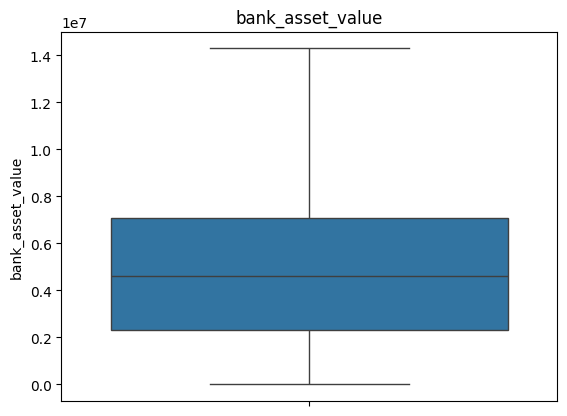

In [166]:
def boxplots(col):
    sns.boxplot(data[col])
    plt.title(col)
    plt.show()

for i in list(data.select_dtypes(exclude=['object']).columns):
    boxplots(i)

In [167]:
data.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

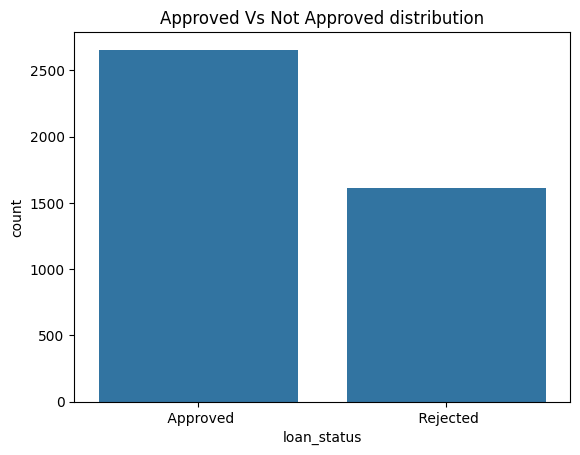

In [168]:
sns.countplot(x='loan_status', data=data)
plt.title("Approved Vs Not Approved distribution")
plt.show()

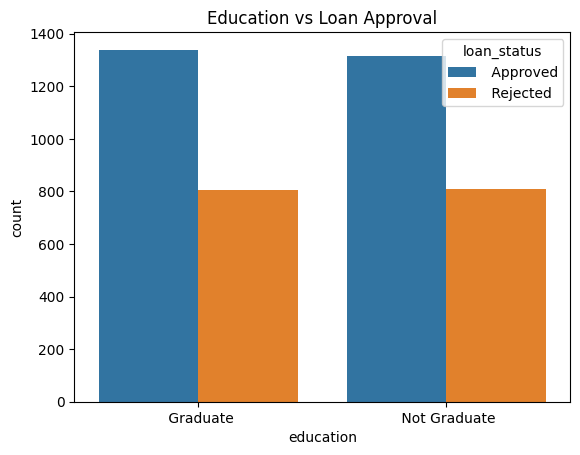

In [169]:
sns.countplot(x='education', hue='loan_status', data=data)
plt.title("Education vs Loan Approval")
plt.show()

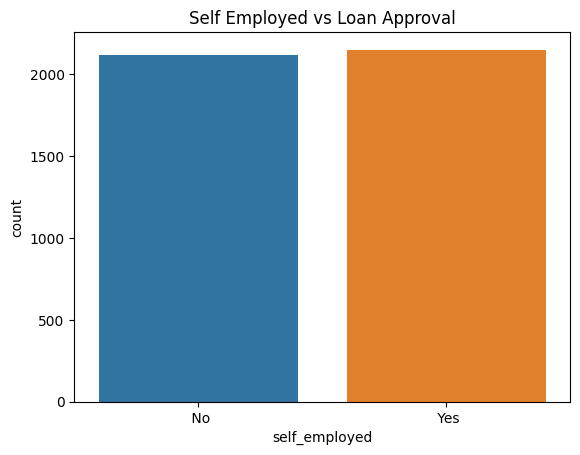

In [170]:
sns.countplot(x='self_employed', hue='self_employed', data=data)
plt.title("Self Employed vs Loan Approval")
plt.show()

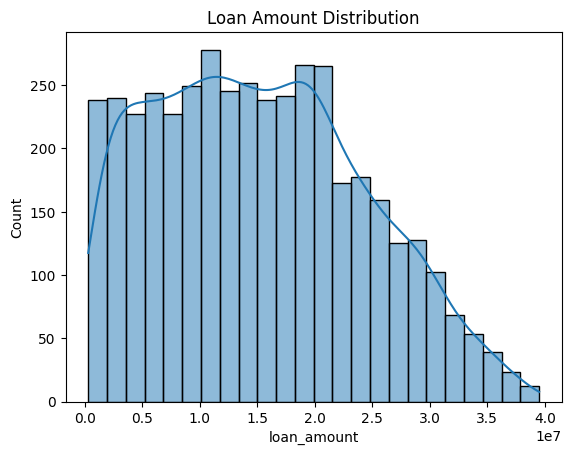

In [171]:
sns.histplot(data['loan_amount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

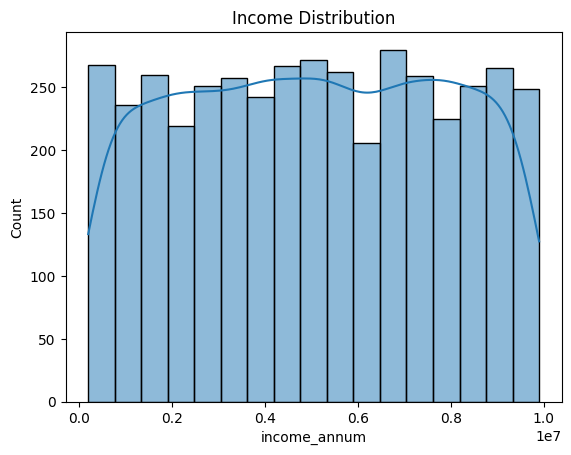

In [172]:
sns.histplot(data['income_annum'], kde=True)
plt.title("Income Distribution")
plt.show()

In [173]:
print(data['loan_status'].unique())

[' Approved' ' Rejected']


In [174]:
data['loan_status'] = data['loan_status'].str.strip()

In [175]:
data['loan_status'] = data['loan_status'].map({
    'Rejected': 0,
    'Approved': 1
})

In [176]:
data.corr(numeric_only=True).round(2)

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
loan_id,1.00,0.01,0.01,0.01,0.01,0.02,0.02,0.02,-0.00,0.01,0.02
no_of_dependents,0.01,1.00,0.01,-0.00,-0.02,-0.01,0.01,-0.00,0.00,0.01,-0.02
income_annum,0.01,0.01,1.00,0.93,0.01,-0.02,0.64,0.64,0.93,0.85,-0.02
loan_amount,0.01,-0.00,0.93,1.00,0.01,-0.02,0.60,0.60,0.86,0.79,0.02
loan_term,0.01,-0.02,0.01,0.01,1.00,0.01,0.01,-0.01,0.01,0.02,-0.11
cibil_score,0.02,-0.01,-0.02,-0.02,0.01,1.00,-0.02,-0.00,-0.03,-0.02,0.77
residential_assets_value,0.02,0.01,0.64,0.60,0.01,-0.02,1.00,0.42,0.59,0.53,-0.01
commercial_assets_value,0.02,-0.00,0.64,0.60,-0.01,-0.00,0.42,1.00,0.59,0.55,0.01
luxury_assets_value,-0.00,0.00,0.93,0.86,0.01,-0.03,0.59,0.59,1.00,0.79,-0.02
bank_asset_value,0.01,0.01,0.85,0.79,0.02,-0.02,0.53,0.55,0.79,1.00,-0.01


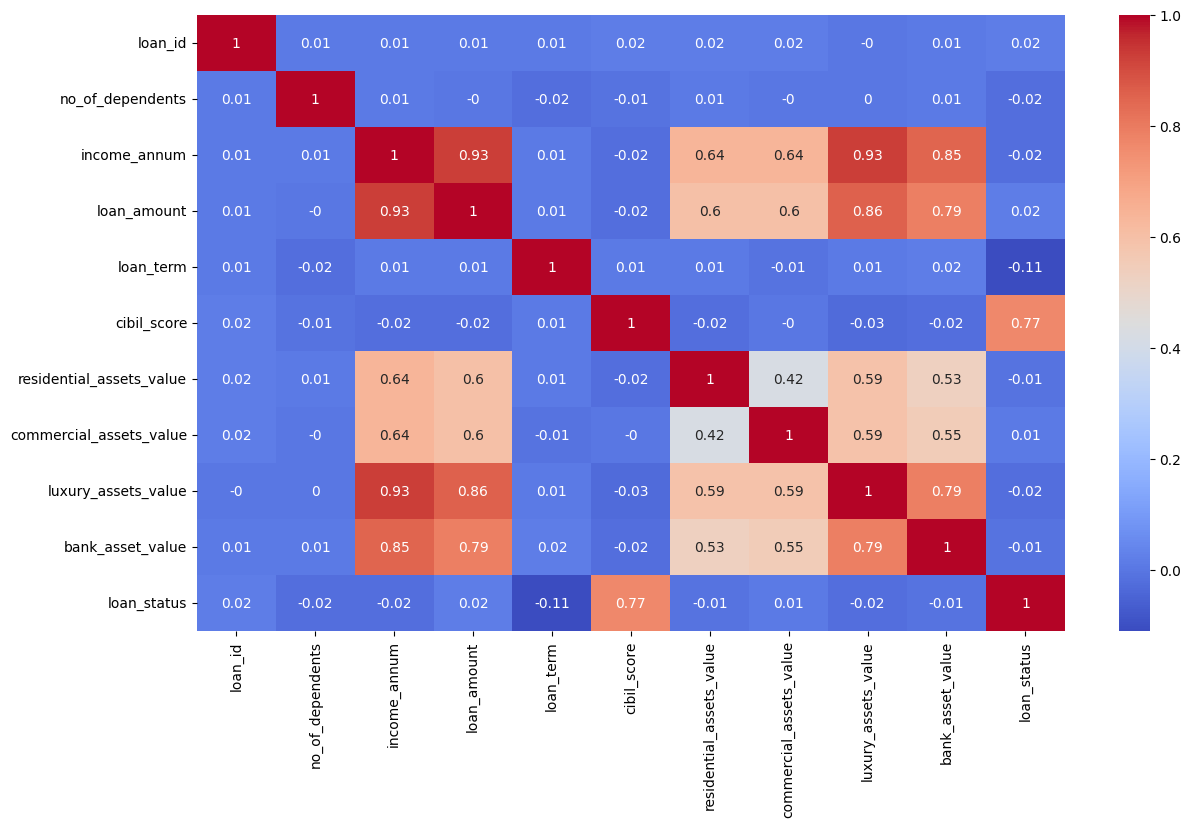

In [177]:
plt.figure(figsize=(14,8))
sns.heatmap(data.corr(numeric_only=True).round(2), annot=True, cmap='coolwarm')
plt.show()

In [178]:
corr_with_target = data.corr(numeric_only=True)['loan_status'].sort_values(ascending=False)
print(corr_with_target)

loan_status                 1.000000
cibil_score                 0.770518
loan_id                     0.017685
loan_amount                 0.016150
commercial_assets_value     0.008799
bank_asset_value           -0.006746
residential_assets_value   -0.014985
income_annum               -0.015189
luxury_assets_value        -0.015465
no_of_dependents           -0.018114
loan_term                  -0.113036
Name: loan_status, dtype: float64


In [179]:
x=data.drop(['loan_id', 'loan_status'], axis=1)
y=data['loan_status']

In [180]:
y.value_counts(normalize=True).round(2)

,proportion
loan_status,
1,0.62
0,0.38


In [181]:
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [182]:
cat_lst=[]
for cols in x_train.columns:
  if x_train[cols].dtypes=="O":
    cat_lst.append(cols)

cat_lst

['education', 'self_employed']

In [183]:
encoder=OneHotEncoder(drop='first', dtype='int', sparse_output=False)
x_train_cat_encoded=encoder.fit_transform(x_train[cat_lst])
x_train_cat_encoded_df=pd.DataFrame(x_train_cat_encoded, index=x_train.index, columns=encoder.get_feature_names_out())
x_train_encoded=pd.concat([x_train.drop(cat_lst, axis=1),x_train_cat_encoded_df], axis=1)
x_train_encoded.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes
1877,4,4800000,14300000,6,795,5900000.0,0.0,11100000,2600000.0,0,0
1729,3,5800000,16700000,18,633,8100000.0,8400000.0,14700000,3700000.0,0,1
164,2,8100000,22300000,18,737,22300000.0,12600000.0,27000000,7300000.0,0,1
2298,2,4400000,13900000,6,810,13200000.0,4200000.0,15000000,5200000.0,1,1
2461,5,6500000,24800000,8,779,7000000.0,9600000.0,15700000,8800000.0,0,0


In [184]:
x_test_cat_encoded=encoder.transform(x_test[cat_lst])
x_test_cat_encoded_df=pd.DataFrame(x_test_cat_encoded, index=x_test.index, columns=encoder.get_feature_names_out())
x_test_encoded=pd.concat([x_test.drop(cat_lst, axis=1), x_test_cat_encoded_df], axis=1)
x_test_encoded.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes
2856,3,8300000,31400000,6,674,1000000.0,1600000.0,17200000,6100000.0,1,1
3176,4,3100000,8200000,18,408,2900000.0,3800000.0,10800000,3100000.0,1,1
477,1,8000000,31900000,12,504,23800000.0,1500000.0,22100000,6000000.0,0,0
4023,0,3800000,13300000,6,655,9600000.0,0.0,8600000,2600000.0,1,0
134,3,1500000,5500000,16,717,2100000.0,800000.0,4400000,1300000.0,1,0


In [185]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
x_vif = x_train_encoded.copy()

In [186]:
vif_data = pd.DataFrame()
vif_data["Feature"] = x_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(x_vif.values, i)
    for i in range(x_vif.shape[1])
]

In [187]:
vif_data = vif_data.sort_values(by="VIF", ascending=False)
print(vif_data)

                     Feature        VIF
1               income_annum  73.689298
7        luxury_assets_value  27.411543
2                loan_amount  27.319411
8           bank_asset_value  12.203673
4                cibil_score   6.480619
3                  loan_term   3.960578
5   residential_assets_value   3.912887
6    commercial_assets_value   3.876599
0           no_of_dependents   2.861764
10        self_employed_ Yes   1.946783
9    education_ Not Graduate   1.921227


In [188]:
x_train_reduced = x_train_encoded.drop([
    'income_annum',
    'loan_amount',
    'luxury_assets_value',
    'bank_asset_value'
], axis=1)

x_test_reduced = x_test_encoded.drop([
    'income_annum',
    'loan_amount',
    'luxury_assets_value',
    'bank_asset_value'
], axis=1)

In [189]:
scaler = MinMaxScaler()
x_train_scaled = scaler.fit_transform(x_train_reduced)
x_test_scaled = scaler.transform(x_test_reduced)

In [190]:
from sklearn.linear_model import LogisticRegression
logit=LogisticRegression()
logit.fit(x_train_scaled, y_train)

LogisticRegression()

In [191]:
y_pred_train=logit.predict(x_train_scaled)
y_pred_test=logit.predict(x_test_scaled)

In [192]:
print("Training Accuracy :", round(accuracy_score(y_train, y_pred_train),2))
print()
print("Test Accuracy :", round(accuracy_score(y_test, y_pred_test),2))

Training Accuracy : 0.91

Test Accuracy : 0.92


In [193]:
print("Classification_report :", classification_report(y_train, y_pred_train))
print()
print("Classification_report :", classification_report(y_test, y_pred_test))

Classification_report :               precision    recall  f1-score   support

           0       0.89      0.89      0.89      1290
           1       0.93      0.93      0.93      2125

    accuracy                           0.91      3415
   macro avg       0.91      0.91      0.91      3415
weighted avg       0.91      0.91      0.91      3415


Classification_report :               precision    recall  f1-score   support

           0       0.90      0.88      0.89       323
           1       0.93      0.94      0.94       531

    accuracy                           0.92       854
   macro avg       0.92      0.91      0.91       854
weighted avg       0.92      0.92      0.92       854



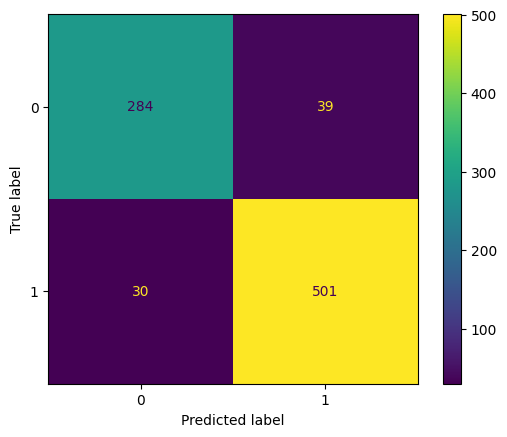

In [194]:
cm=ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test)

In [195]:
scaler=MinMaxScaler()
x_train_scaled=scaler.fit_transform(x_train_encoded)
x_train_scaled_df=pd.DataFrame(x_train_scaled, index=x_train.index, columns=x_train_encoded.columns)
x_train_scaled_df.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes
1877,0.8,0.474227,0.363636,0.222222,0.825000,0.239521,0.000000,0.277635,0.181818,0.0,0.0
1729,0.6,0.577320,0.425974,0.888889,0.555000,0.327345,0.492669,0.370180,0.258741,0.0,1.0
164,0.4,0.814433,0.571429,0.888889,0.728333,0.894212,0.739003,0.686375,0.510490,0.0,1.0
2298,0.4,0.432990,0.353247,0.222222,0.850000,0.530938,0.246334,0.377892,0.363636,1.0,1.0
2461,1.0,0.649485,0.636364,0.333333,0.798333,0.283433,0.563050,0.395887,0.615385,0.0,0.0


In [196]:
x_test_scaled=scaler.transform(x_test_encoded)
x_test_scaled_df=pd.DataFrame(x_test_scaled, index=x_test.index, columns=x_test_encoded.columns)
x_test_scaled_df.head()

,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,education_ Not Graduate,self_employed_ Yes
2856,0.6,0.835052,0.807792,0.222222,0.623333,0.043912,0.093842,0.434447,0.426573,1.0,1.0
3176,0.8,0.298969,0.205195,0.888889,0.180000,0.119760,0.222874,0.269923,0.216783,1.0,1.0
477,0.2,0.804124,0.820779,0.555556,0.340000,0.954092,0.087977,0.560411,0.419580,0.0,0.0
4023,0.0,0.371134,0.337662,0.222222,0.591667,0.387226,0.000000,0.213368,0.181818,1.0,0.0
134,0.6,0.134021,0.135065,0.777778,0.695000,0.087824,0.046921,0.105398,0.090909,1.0,0.0


In [197]:
from sklearn.tree import DecisionTreeClassifier
dtree=DecisionTreeClassifier(max_depth=7, random_state=42)
dtree.fit(x_train_scaled, y_train)

DecisionTreeClassifier(max_depth=7, random_state=42)

In [198]:
y_predtrain_dtree=dtree.predict(x_train_scaled)
y_predtest_dtree=dtree.predict(x_test_scaled)

In [199]:
print("Training Accuracy :", round(accuracy_score(y_train, y_predtrain_dtree),2))
print()
print("Test Accuracy :", round(accuracy_score(y_test, y_predtest_dtree),2))

Training Accuracy : 0.98

Test Accuracy : 0.97


In [200]:
print("Classification_report :", classification_report(y_train, y_predtrain_dtree))
print()
print("Classification_report :", classification_report(y_test, y_predtest_dtree))

Classification_report :               precision    recall  f1-score   support

           0       0.99      0.97      0.98      1290
           1       0.98      1.00      0.99      2125

    accuracy                           0.98      3415
   macro avg       0.99      0.98      0.98      3415
weighted avg       0.98      0.98      0.98      3415


Classification_report :               precision    recall  f1-score   support

           0       0.98      0.94      0.96       323
           1       0.97      0.99      0.98       531

    accuracy                           0.97       854
   macro avg       0.97      0.96      0.97       854
weighted avg       0.97      0.97      0.97       854



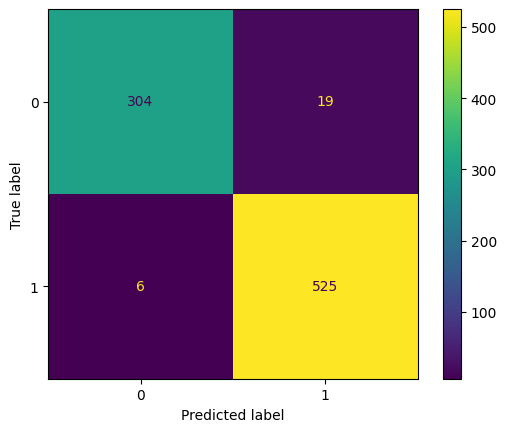

In [201]:
cm=ConfusionMatrixDisplay.from_predictions(y_test, y_predtest_dtree)

In [202]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=50, criterion='gini', max_depth=5, random_state=42 )
rf.fit(x_train_scaled, y_train)

RandomForestClassifier(max_depth=5, n_estimators=50, random_state=42)

In [203]:
y_predtrain_rf=rf.predict(x_train_scaled)
y_predtest_rf=rf.predict(x_test_scaled)

In [204]:
print("Training Accuracy :", round(accuracy_score(y_train, y_predtrain_rf),2))
print()
print("Test Accuracy :", round(accuracy_score(y_test, y_predtest_rf),2))

Training Accuracy : 0.98

Test Accuracy : 0.98


In [205]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    rf,
    x_train_scaled,
    y_train,
    cv=5,
    scoring="roc_auc"
)

print(cv_scores)
print("Mean ROC-AUC:", cv_scores.mean())

[0.99606931 0.99920657 0.98917465 0.99601459 0.9951026 ]
Mean ROC-AUC: 0.9951135430916553


In [206]:
print("Classification_report :", classification_report(y_train, y_predtrain_rf))
print()
print("Classification_report :", classification_report(y_test, y_predtest_rf))

Classification_report :               precision    recall  f1-score   support

           0       0.97      0.98      0.97      1290
           1       0.99      0.98      0.98      2125

    accuracy                           0.98      3415
   macro avg       0.98      0.98      0.98      3415
weighted avg       0.98      0.98      0.98      3415


Classification_report :               precision    recall  f1-score   support

           0       0.98      0.96      0.97       323
           1       0.98      0.99      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



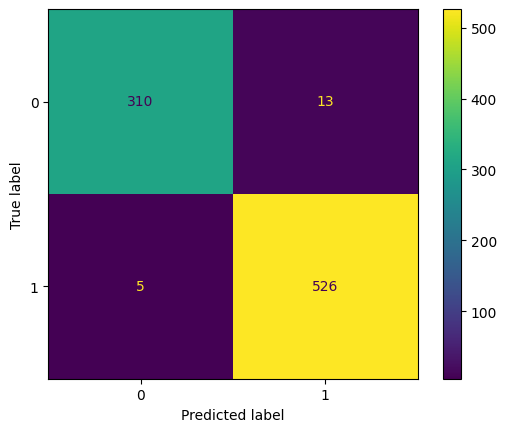

In [207]:
cm=ConfusionMatrixDisplay.from_predictions(y_test, y_predtest_rf)

In [208]:
from xgboost import XGBClassifier
xgb=XGBClassifier()
xgb.fit(x_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [209]:
y_predtrain_xgb=xgb.predict(x_train_scaled)
y_predtest_xgb=xgb.predict(x_test_scaled)

In [210]:
print("Training Accuracy :", round(accuracy_score(y_train, y_predtrain_xgb),2))
print()
print("Test Accuracy :", round(accuracy_score(y_test, y_predtest_xgb),2))

Training Accuracy : 1.0

Test Accuracy : 0.98


In [211]:
print("Classification_report :", classification_report(y_train, y_predtrain_xgb))
print()
print("Classification_report :", classification_report(y_test, y_predtest_xgb))

Classification_report :               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1290
           1       1.00      1.00      1.00      2125

    accuracy                           1.00      3415
   macro avg       1.00      1.00      1.00      3415
weighted avg       1.00      1.00      1.00      3415


Classification_report :               precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.98      0.98      0.98       531

    accuracy                           0.98       854
   macro avg       0.98      0.98      0.98       854
weighted avg       0.98      0.98      0.98       854



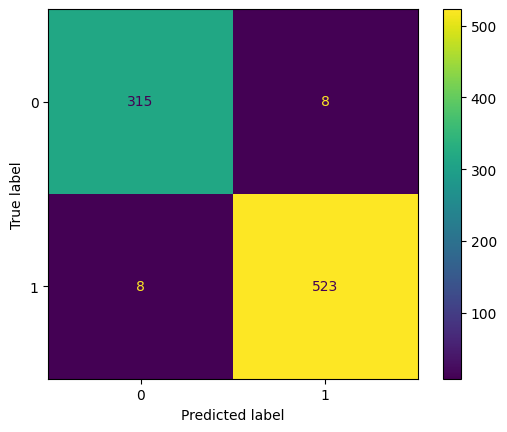

In [212]:
cm=ConfusionMatrixDisplay.from_predictions(y_test, y_predtest_xgb)

In [213]:
y_prob_rf = rf.predict_proba(x_test_scaled)[:,1]
rf_roc_auc=roc_auc_score(y_test, y_prob_rf)
print(rf_roc_auc)

0.9953064782261403


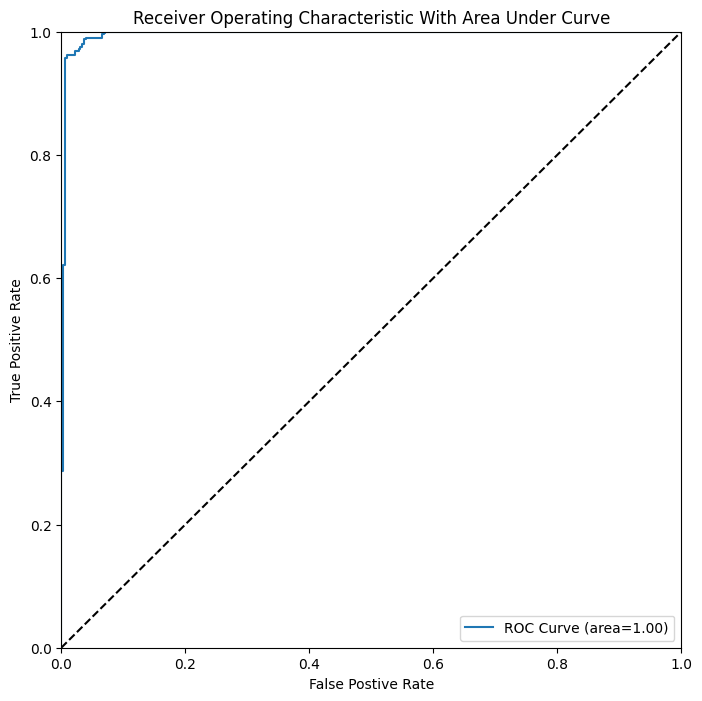

In [214]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(8,8))
plt.plot(fpr, tpr, label=f"ROC Curve (area={rf_roc_auc:.2f})")
plt.plot([0,1], [0,1],'k--')
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.xlabel("False Postive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic With Area Under Curve")
plt.legend(loc="lower right")
plt.show()

In [215]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_test),
        accuracy_score(y_test, y_predtest_dtree),
        accuracy_score(y_test, y_predtest_rf),
        accuracy_score(y_test, y_predtest_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_test),
        precision_score(y_test, y_predtest_dtree),
        precision_score(y_test, y_predtest_rf),
        precision_score(y_test, y_predtest_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_test),
        recall_score(y_test, y_predtest_dtree),
        recall_score(y_test, y_predtest_rf),
        recall_score(y_test, y_predtest_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_test),
        f1_score(y_test, y_predtest_dtree),
        f1_score(y_test, y_predtest_rf),
        f1_score(y_test, y_predtest_xgb)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.919204,0.927778,0.943503,0.935574
1,Decision Tree,0.970726,0.965074,0.988701,0.976744
2,Random Forest,0.978923,0.975881,0.990584,0.983178
3,XGBoost,0.981265,0.984934,0.984934,0.984934


In [216]:
imp = rf.feature_importances_

# Create dataframe
featNames = x_train_scaled_df.columns
featImp = pd.DataFrame({
    "Feature": featNames,
    "Importance": imp
})

In [217]:
featImp = featImp.sort_values(by="Importance", ascending=False).reset_index(drop=True)

featImp

,Feature,Importance
0,cibil_score,0.875635
1,loan_term,0.063371
2,loan_amount,0.015085
3,luxury_assets_value,0.010995
4,commercial_assets_value,0.008921
5,bank_asset_value,0.007962
6,income_annum,0.007371
7,residential_assets_value,0.006414
8,no_of_dependents,0.003388
9,self_employed_ Yes,0.000467
